In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import joblib

In [141]:
df = pd.read_csv('Churn_Modelling.csv')
df.sample(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7343,7344,15763194,Milanesi,643,France,Male,34,7,0.00,2,0,1,100304.13,0
764,765,15672056,Kenenna,710,Germany,Male,43,2,140080.32,3,1,1,157908.19,1
6900,6901,15806922,Bergamaschi,674,Spain,Female,41,4,126605.14,1,1,1,166694.93,0


In [142]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [143]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
6970,696,66,7,119499.42,2,1,1,174027.30,0,True,False,False
3929,646,36,6,144773.29,2,1,0,53217.30,0,True,False,False
3600,506,57,6,0.00,2,0,1,194421.12,1,False,False,False
1673,652,26,1,131908.35,1,1,1,179269.79,0,True,False,False
5150,515,37,0,196853.62,1,1,1,132770.11,0,False,False,False


In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.6 KB


In [145]:
def map_bools(df):
    for col in df.columns:
        if df[col].dtype == 'bool':
            df[col] = df[col].map({True: 1, False: 0})
    return df

df = map_bools(df)


In [146]:
df.sample(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
2199,762,29,6,141389.06,1,1,0,54122.89,0,0,0,1
9244,546,25,3,132837.70,1,1,0,131647.31,0,1,0,0
5553,666,31,3,123212.08,2,1,1,112157.31,0,1,0,1


In [147]:
x=df.drop(columns=['Exited'])
y=df['Exited']

In [148]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=23)

In [149]:
sc=StandardScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [150]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [156]:
model=Sequential()

model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(20, activation='relu'))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
his=model.fit(x_train_scaled, y_train, epochs=30,validation_split=0.2)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7644 - loss: 0.5444 - val_accuracy: 0.8000 - val_loss: 0.4721
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7986 - loss: 0.4575 - val_accuracy: 0.8125 - val_loss: 0.4305
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8203 - loss: 0.4267 - val_accuracy: 0.8194 - val_loss: 0.4209
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8292 - loss: 0.4112 - val_accuracy: 0.8319 - val_loss: 0.4049
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8364 - loss: 0.3988 - val_accuracy: 0.8400 - val_loss: 0.3928
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8462 - loss: 0.3865 - val_accuracy: 0.8469 - val_loss: 0.3832
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8506 - loss: 0.3731 - val_accuracy: 0.8481 - val_loss: 0.3707
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8575 - loss: 0.3620 - val_accuracy: 0.8537 - val_

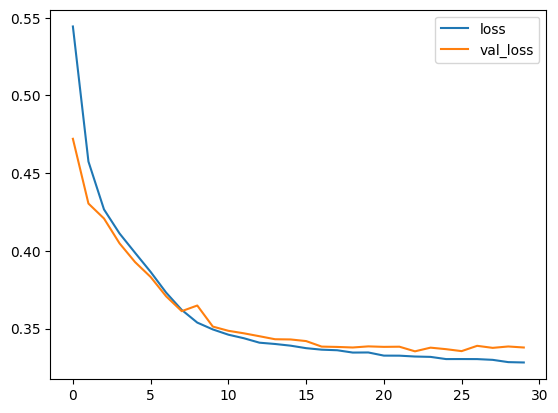

In [157]:
plt.plot(his.history['loss'],label='loss')
plt.plot(his.history['val_loss'],label='val_loss')
plt.legend()

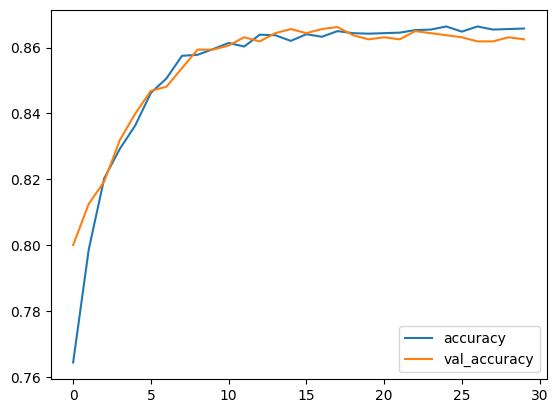

In [158]:
plt.plot(his.history['accuracy'],label='accuracy')
plt.plot(his.history['val_accuracy'],label='val_accuracy')
plt.legend()

In [159]:
y_predict=np.where(model.predict(x_test_scaled)>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [160]:
acc=accuracy_score(y_test,y_predict)
acc

0.8555

In [164]:
final='model.sav'
joblib.dump(model,open(final,'wb'))
